In [1]:
#CONFRONTO PRODUZIONE/FABBISOGNO

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

fabbisogno = pd.read_csv('Fabbisogno_Energetico_Mensile.csv')
produzione  = pd.read_csv('Rinnovabili_Pulito:Mesi_2021_2026.csv')

In [48]:
fabbisogno['Date'] = pd.to_datetime(fabbisogno['Date'])
fabbisogno['ore_mese'] = fabbisogno['Date'].dt.days_in_month * 24
fabbisogno['Fabbisogno_GWh'] = fabbisogno['Total Load [MW]'] * fabbisogno['ore_mese'] / 1000
fabbisogno['Date'] = fabbisogno['Date'].dt.strftime('%Y-%m')

In [49]:
produzione['Date'] = produzione['Date'].astype(str)
produzione['Totale_Rinnovabili_GWh'] = (
    produzione['Biomass'] +
    produzione['Geothermal'] +
    produzione['Hydro'] +
    produzione['Photovoltaic'] +
    produzione['Wind']
)

In [50]:
df = pd.merge(
    fabbisogno[['Date', 'Fabbisogno_GWh']],
    produzione[['Date', 'Totale_Rinnovabili_GWh', 'Biomass', 'Geothermal', 'Hydro', 'Photovoltaic', 'Wind']],
    on='Date'
)
df

,Date,Fabbisogno_GWh,Totale_Rinnovabili_GWh,Biomass,Geothermal,Hydro,Photovoltaic,Wind
0,2021-01,27060.94656,9296.686,1579.200,464.485,3735.671,902.158,2615.172
1,2021-02,24960.29088,8558.340,1418.232,426.850,3590.643,1423.348,1699.267
2,2021-03,26661.15072,9463.096,1566.634,475.560,3263.113,2319.726,1838.063
3,2021-04,24472.67760,9217.580,1487.184,459.040,3345.190,2371.714,1554.452
4,2021-05,24967.30824,11859.146,1474.692,465.170,4977.786,2941.709,1999.789
...,...,...,...,...,...,...,...,...
57,2025-10,25397.30304,10056.251,1156.928,440.780,2816.993,3321.774,2319.776
58,2025-11,25482.13920,8298.877,1163.135,433.660,2617.487,2280.879,1803.716
59,2025-12,26147.14344,7291.763,1442.446,445.860,2156.282,1777.739,1469.436
60,2026-01,27827.47488,8834.816,1233.227,416.310,2559.285,1651.102,2974.892


In [51]:
#Copertura %: rinnovabili / fabbisogno 
df['Copertura_%'] = (df['Totale_Rinnovabili_GWh'] / df['Fabbisogno_GWh']) * 100
df['Copertura_%']

0     34.354622
1     34.287822
2     35.493952
3     37.664779
4     47.498697
        ...    
57    39.595744
58    32.567427
59    27.887417
60    31.748536
61    35.826902
Name: Copertura_%, Length: 62, dtype: float64

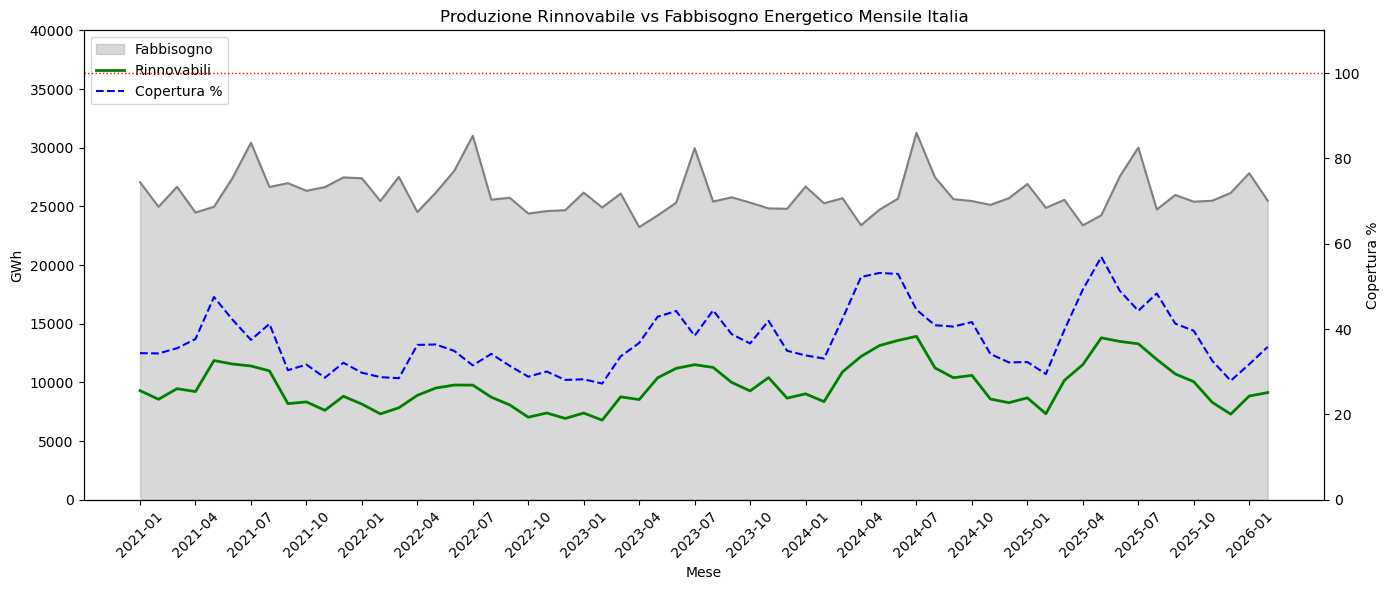

In [57]:
# CELL 6 — Grafico
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(df['Date'], df['Fabbisogno_GWh'], alpha=0.3, color='gray', label='Fabbisogno')
ax1.plot(df['Date'], df['Fabbisogno_GWh'], color='gray', linewidth=1.5)
ax1.plot(df['Date'], df['Totale_Rinnovabili_GWh'], color='green', linewidth=2, label='Rinnovabili')
ax1.set_ylabel('GWh')
ax1.set_xlabel('Mese')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Copertura_%'], color='blue', linewidth=1.5, linestyle='--', label='Copertura %')
ax2.set_ylabel('Copertura %')
ax2.axhline(y=100, color='red', linestyle=':', linewidth=1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Produzione Rinnovabile vs Fabbisogno Energetico Mensile Italia')
plt.tight_layout()
plt.xticks(df['Date'][::3], rotation=45)
ax1.set_ylim(0, 40000)
ax2.set_ylim(0,110)
plt.savefig("Produzione_Rinnovabile_vs_Fabbisogno.jpeg", dpi=300, bbox_inches='tight')
plt.show()

In [46]:
print("Fabbisogno medio (GWh):", df['Fabbisogno_GWh'].mean().round(1))
print("Rinnovabili medie (GWh):", df['Totale_Rinnovabili_GWh'].mean().round(1))
print("Esempio gennaio 2021:", df[df['Date']=='2021-01'][['Fabbisogno_GWh','Totale_Rinnovabili_GWh']].values)

Fabbisogno medio (GWh): 26075.5
Rinnovabili medie (GWh): 9.7
Esempio gennaio 2021: [[2.70609466e+04 9.29600000e+00]]


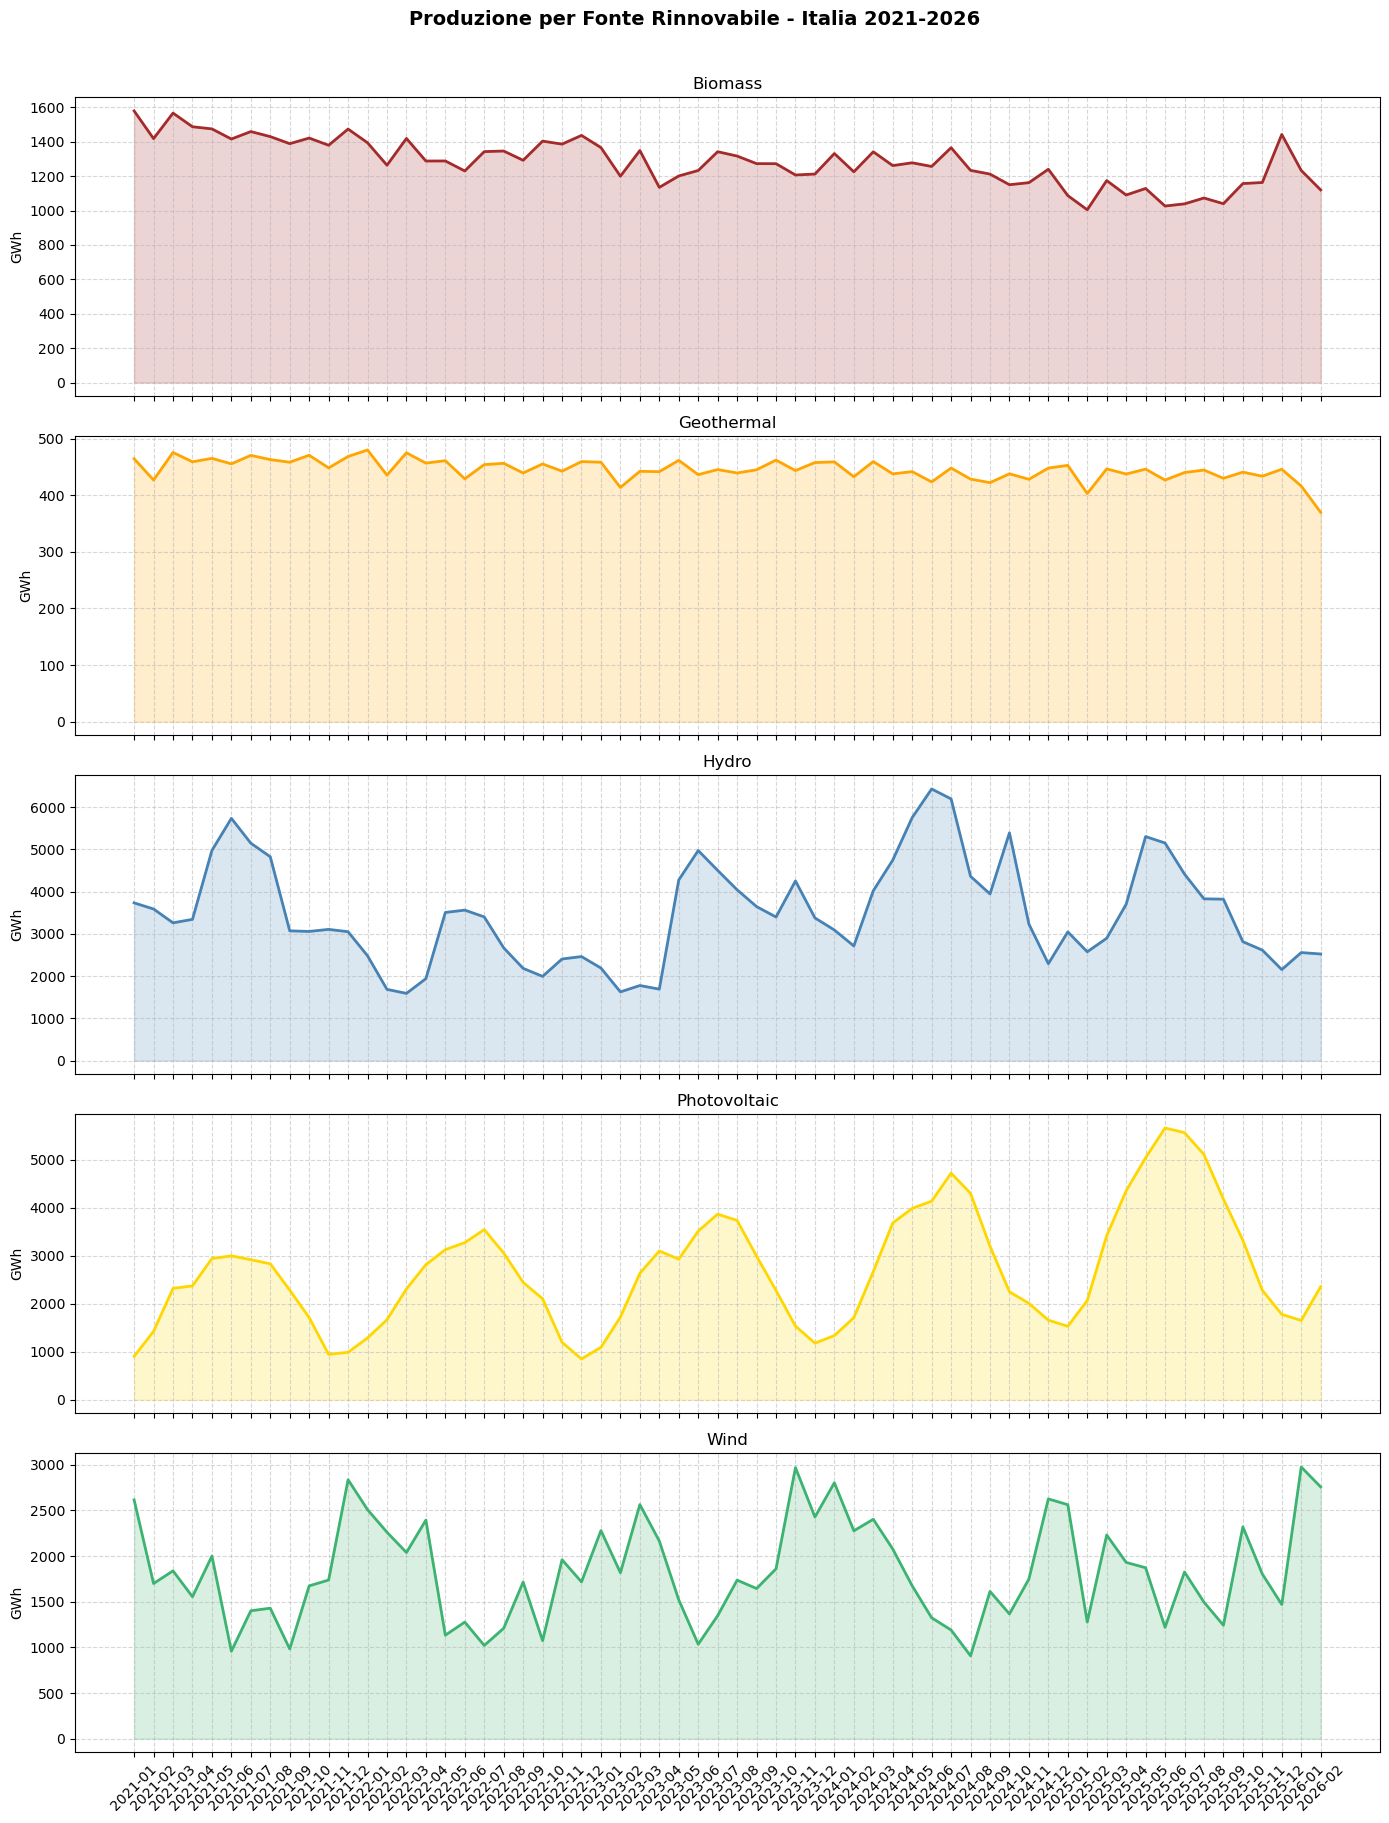

In [60]:
fonti = ['Biomass', 'Geothermal', 'Hydro', 'Photovoltaic', 'Wind']
colori = ['brown', 'orange', 'steelblue', 'gold', 'mediumseagreen']

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for ax, fonte, colore in zip(axes, fonti, colori):
    ax.plot(df['Date'], df[fonte], color=colore, linewidth=2)
    ax.fill_between(df['Date'], df[fonte], alpha=0.2, color=colore)
    ax.set_ylabel('GWh')
    ax.set_title(fonte)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Produzione per Fonte Rinnovabile - Italia 2021-2026', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("Produzione_per_Fonte.jpeg", dpi=300, bbox_inches='tight')
plt.show()